# Slide 1 - From Raw Echo Frame to Structured Measurements



In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return p
    raise RuntimeError("Open this notebook from the Master repo (or a parent path that contains app/pipeline).")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

DICOM_CANDIDATES = [
    REPO / "91243943_0007.dcm",
    REPO / "91243943_00007.dcm",
    REPO / "notebooks" / "91243943_0007.dcm",
]
DICOM_PATH = next((p for p in DICOM_CANDIDATES if p.is_file()), None)
if DICOM_PATH is None:
    raise FileNotFoundError(f"No sample DICOM found. Tried: {DICOM_CANDIDATES}")

print("REPO:", REPO)
print("DICOM:", DICOM_PATH)

REPO: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master
DICOM: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master\91243943_0007.dcm


## Slide 2 - Raw Input Frame



frame shape: (708, 1016, 3) dtype: uint8


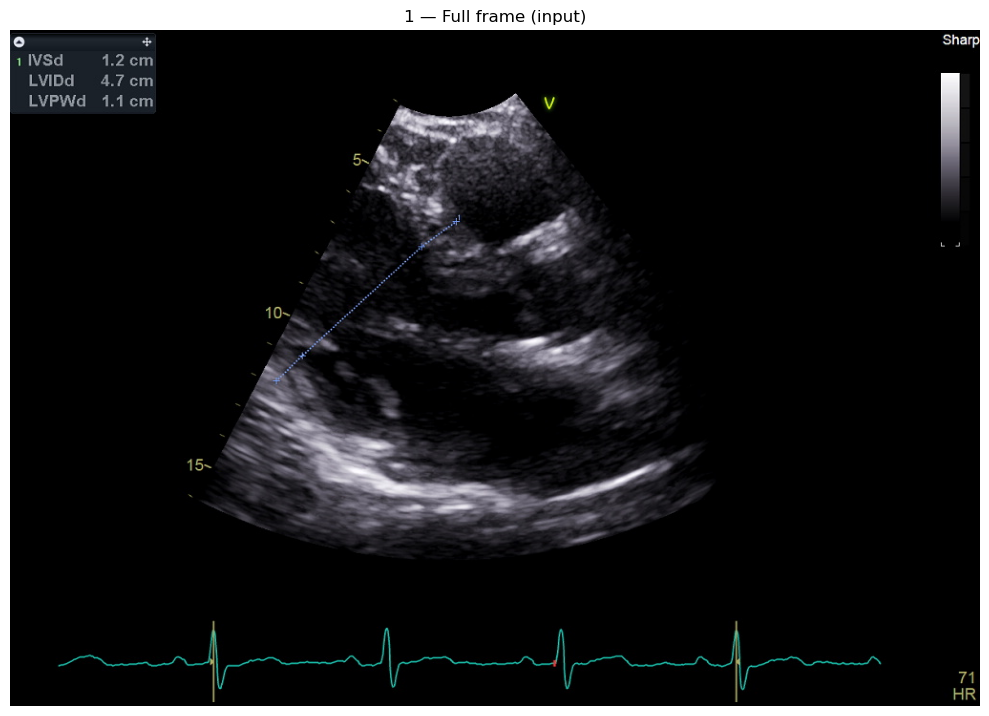

In [2]:
from app.io.dicom_loader import load_dicom_series

series = load_dicom_series(DICOM_PATH, load_pixels=True)
frame = series.raw_frames[0]
print("frame shape:", frame.shape, "dtype:", frame.dtype)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(frame)
ax.set_title("1 — Full frame (input)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Slide 3 - Detect Measurement Panel (ROI Localization)



RoiDetection(present=True, bbox=(0, 7, 153, 81), confidence=0.9488420882756394)


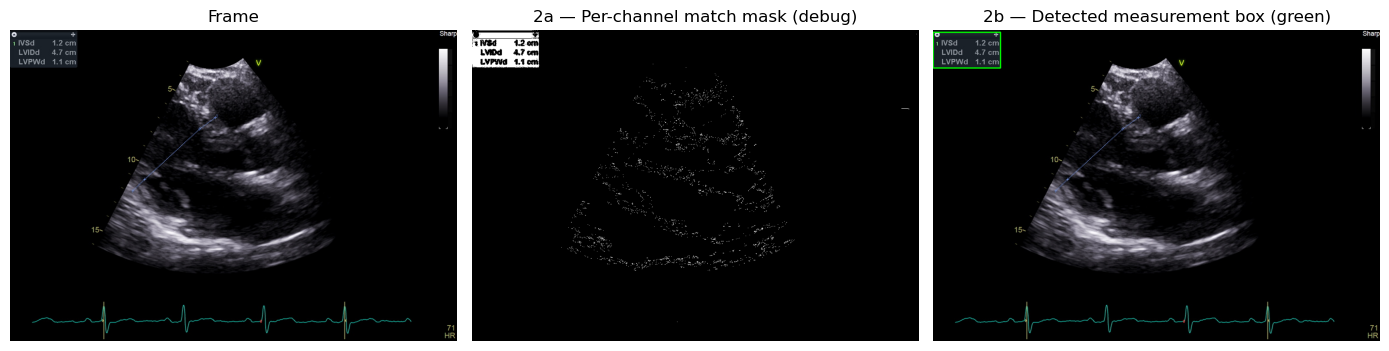

In [3]:
import cv2

from app.pipeline.layout.echo_ocr_box_detector import TopLeftBlueGrayBoxDetector, _color_match_mask

detector = TopLeftBlueGrayBoxDetector()
detection = detector.detect(frame)
print(detection)

if not detection.present or detection.bbox is None:
    raise RuntimeError("ROI not found — check frame / detector parameters.")

rgb = frame[..., :3].astype(np.int16)
mask = _color_match_mask(rgb, detector.box_color, detector.color_tolerance).astype(np.uint8) * 255

x, y, bw, bh = detection.bbox
overlay = frame.copy()
cv2.rectangle(overlay, (x, y), (x + bw, y + bh), (0, 255, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(frame)
axes[0].set_title("Frame")
axes[1].imshow(mask, cmap="gray")
axes[1].set_title("2a — Per-channel match mask (debug)")
axes[2].imshow(overlay)
axes[2].set_title("2b — Detected measurement box (green)")
for a in axes:
    a.axis("off")
plt.tight_layout()
plt.show()

## Slide 4 - Crop the ROI



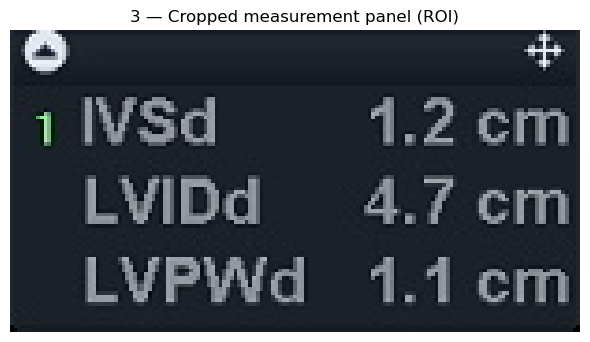

In [4]:
roi = frame[y : y + bh, x : x + bw].copy()
fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(roi)
ax.set_title("3 — Cropped measurement panel (ROI)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Slide 5 - Scout OCR Pass on Whole ROI



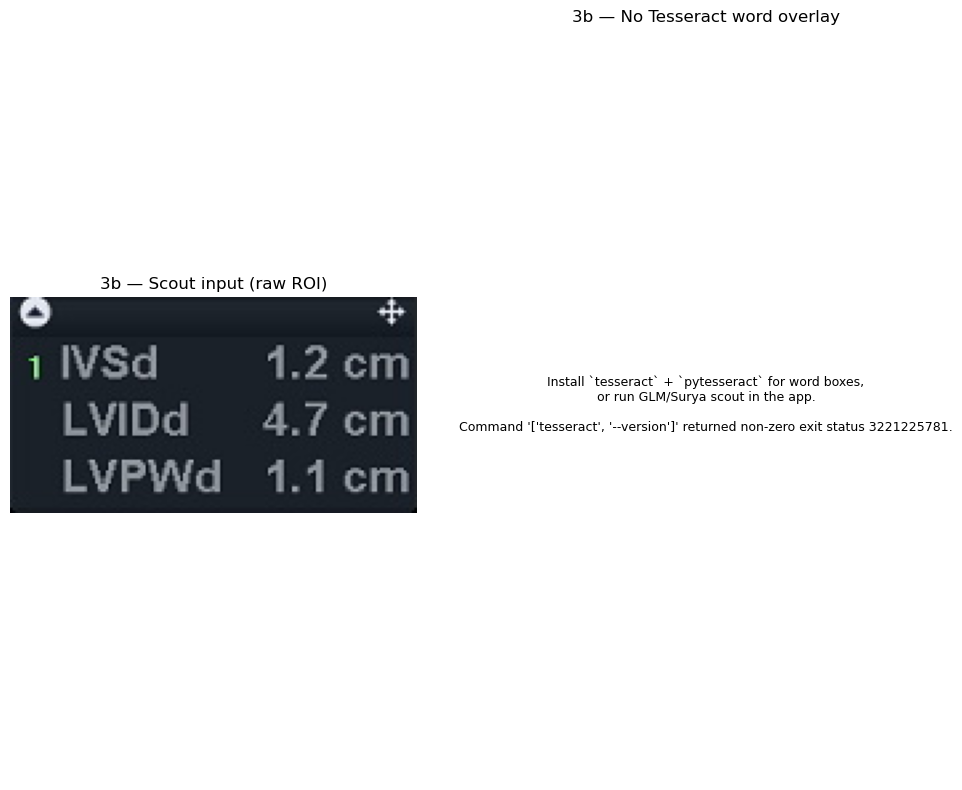

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
axes[0].imshow(roi)
axes[0].set_title("3b — Scout input (raw ROI)")
axes[0].axis("off")

scout_vis = roi.copy()
n_boxes = 0
try:
    import pytesseract
    from pytesseract import Output

    gray_roi = cv2.cvtColor(roi, cv2.COLOR_RGB2GRAY) if roi.ndim == 3 else roi
    data = pytesseract.image_to_data(gray_roi, output_type=Output.DICT, config="--oem 3 --psm 6")
    for i, txt in enumerate(data.get("text", [])):
        if not str(txt).strip():
            continue
        try:
            conf = int(data["conf"][i])
        except (TypeError, ValueError):
            conf = -1
        if conf < 0:
            continue
        xa, ya, wa, ha = data["left"][i], data["top"][i], data["width"][i], data["height"][i]
        cv2.rectangle(scout_vis, (xa, ya), (xa + wa, ya + ha), (0, 200, 255), 1)
        n_boxes += 1
    axes[1].imshow(scout_vis)
    axes[1].set_title(f"3b — Word boxes (Tesseract demo, n={n_boxes})")
except Exception as exc:
    axes[1].text(
        0.5,
        0.5,
        "Install `tesseract` + `pytesseract` for word boxes,\nor run GLM/Surya scout in the app.\n\n"
        + str(exc),
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        fontsize=9,
    )
    axes[1].set_title("3b — No Tesseract word overlay")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Slide 6 - Segment ROI into Ordered Text Lines

Default **`adaptive`**: OCR token rows when the pipeline passes token boxes, otherwise horizontal projection on the **full** panel ROI (`LineSegmenter` uses **no** header trim by default). **`fixed_pitch`** (stripes at ~`target_line_height_px`) remains available via `segmentation_mode="fixed_pitch"`. **`debug_row_projection_scan`** plots the ink mask and row profile below `header_trim_px` (0 here); that view aligns with **`adaptive`** projection fallback, not necessarily with fixed-pitch stripe boxes.


segmentation_mode: adaptive
header_trim_px: 0
lines: 4
debug: {'line_count': 4, 'header_trim_px': 0, 'refined_line_splits': 0, 'segmentation_mode': 'adaptive'}


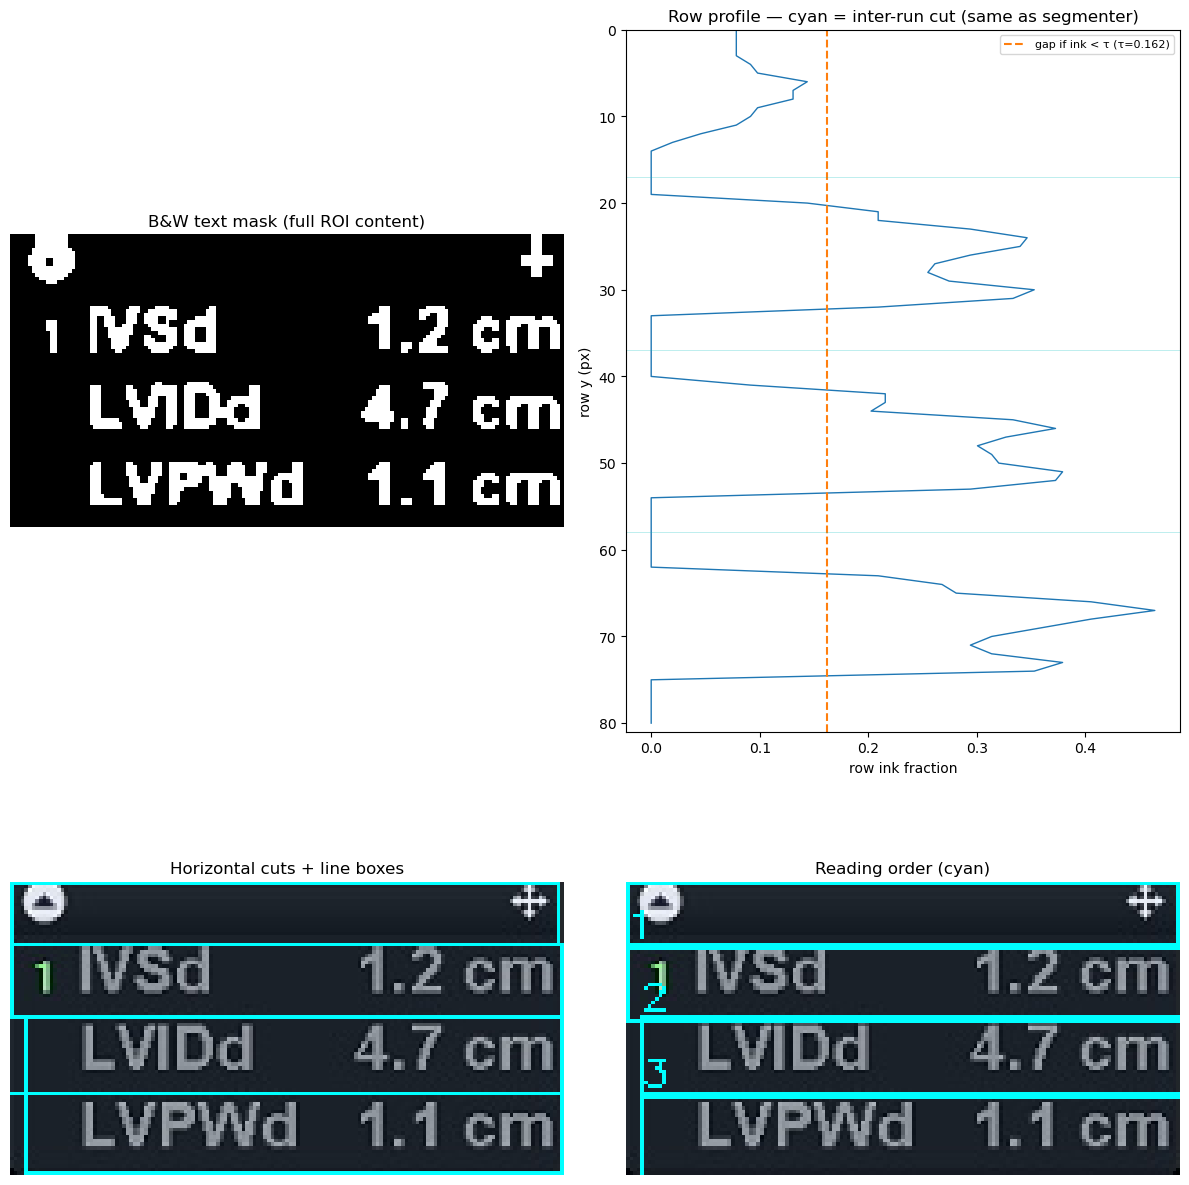

In [6]:
import importlib

import numpy as np
import cv2

from app.pipeline.echo_ocr_pipeline import (
    DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
    DEFAULT_SEGMENTATION_MODE,
    DEFAULT_TARGET_LINE_HEIGHT_PX,
)

# Reload so edits to line_segmenter.py apply without restarting the kernel.
import app.pipeline.layout.line_segmenter as _line_segmenter_mod

importlib.reload(_line_segmenter_mod)
LineSegmenter = _line_segmenter_mod.LineSegmenter

segmenter = LineSegmenter(
    segmentation_mode=DEFAULT_SEGMENTATION_MODE,
    target_line_height_px=DEFAULT_TARGET_LINE_HEIGHT_PX,
    extra_left_pad_px=DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
)
segmentation = segmenter.segment(roi, tokens=None)
print("segmentation_mode:", DEFAULT_SEGMENTATION_MODE)
print("header_trim_px:", segmentation.header_trim_px)
print("lines:", len(segmentation.lines))
print("debug:", segmentation.debug)

ht = segmentation.header_trim_px
scan = segmenter.debug_row_projection_scan(roi, header_trim_px=ht)
mask_u8 = scan["mask_u8"]
row_ink = scan["row_ink"]
tau = scan["tau"]
gap_mid_y_content = scan["gap_mid_y_content"]
h, w = scan["content_shape"]

vis_cuts = roi.copy()
for my in gap_mid_y_content:
    yy = int(my) + ht
    cv2.line(vis_cuts, (0, yy), (w - 1, yy), (0, 255, 255), 1, cv2.LINE_8)
for line in segmentation.lines:
    x1, y1, bw, bh = line.bbox
    cv2.rectangle(vis_cuts, (x1, y1), (x1 + bw - 1, y1 + bh - 1), (0, 255, 255), 1, cv2.LINE_8)

vis_numbered = roi.copy()
for line in segmentation.lines:
    lx, ly, lw_, lh_ = line.bbox
    cv2.rectangle(vis_numbered, (lx, ly), (lx + lw_, ly + lh_), (0, 255, 255), 1, cv2.LINE_8)
    cv2.putText(
        vis_numbered,
        str(line.order),
        (lx, max(0, ly - 2)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.35,
        (0, 255, 255),
        1,
        cv2.LINE_8,
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 14))
axes[0, 0].imshow(mask_u8, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("B&W text mask (full ROI content)")
axp = axes[0, 1]
axp.plot(row_ink, np.arange(h), color="C0", lw=1)
axp.axvline(tau, color="C1", ls="--", label=f"gap if ink < τ (τ={tau:.3f})")
axp.set_ylim(h, 0)
axp.set_xlabel("row ink fraction")
axp.set_ylabel("row y (px)")
for my in gap_mid_y_content:
    axp.axhline(my, color="c", alpha=0.45, lw=0.4)
axp.legend(loc="upper right", fontsize=8)
axp.set_title("Row profile — cyan = inter-run cut (same as segmenter)")
axes[1, 0].imshow(vis_cuts)
axes[1, 0].set_title("Horizontal cuts + line boxes")
axes[1, 1].imshow(vis_numbered)
axes[1, 1].set_title("Reading order (cyan)")
for a in (axes[0, 0], axes[1, 0], axes[1, 1]):
    a.axis("off")
plt.tight_layout()
plt.show()


## Slide 7 - Raw Line Crops



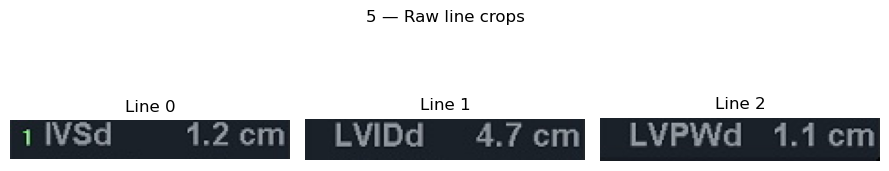

In [7]:
from app.pipeline.transcription.line_transcriber import crop_segment

usable_segments = segmentation.lines[1:]
line_crops = [crop_segment(roi, seg) for seg in usable_segments]
n = len(line_crops)
cols = min(4, max(1, n))
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.2 * rows))
axes = np.atleast_1d(axes).ravel()
for i, crop in enumerate(line_crops):
    axes[i].imshow(crop)
    axes[i].set_title(f"Line {i}")
    axes[i].axis("off")
for j in range(len(line_crops), len(axes)):
    axes[j].axis("off")
plt.suptitle("5 — Raw line crops", y=1.02)
plt.tight_layout()
plt.show()

## Slide 8 - Preprocessing Pipeline (One Line, Step by Step)

## What appears on screen
Three-panel comparison for one line:
1. Raw grayscale (same resolution as the line crop)
2. **×3 Lanczos grayscale only** — input style that scored best for **GLM-OCR** in the broad preprocessing sweep (no unsharp, no Otsu, no morph)
3. **Default binarized pipeline** — unsharp → ×3 Lanczos → Otsu → morph close (still useful for Tesseract-style engines)

## Preprocessing experiments (GLM-OCR, labeled validation)
We ran a headless sweep over 15 line-preprocessing configs (`app/tools/batch/sweep_preprocessing_headless.py`, results under `artifacts/ocr_redesign/preprocess_sweep_glm_broad/`). On the p10 validation slice (490 labeled lines), **top exact match (~95.5%)** tied **gray_x3_lanczos**, **no_preprocess_gray** (1× gray), and **unsharp_x3_lanczos**; among those, **gray_x3_lanczos** is the practical pick (upscale for small crops, fewer moving parts than the full panel default). **Adaptive-threshold** variants scored much lower (~39% exact). The default Otsu+morph stack sat around **~94.5%** exact with occasional file-level OCR errors.



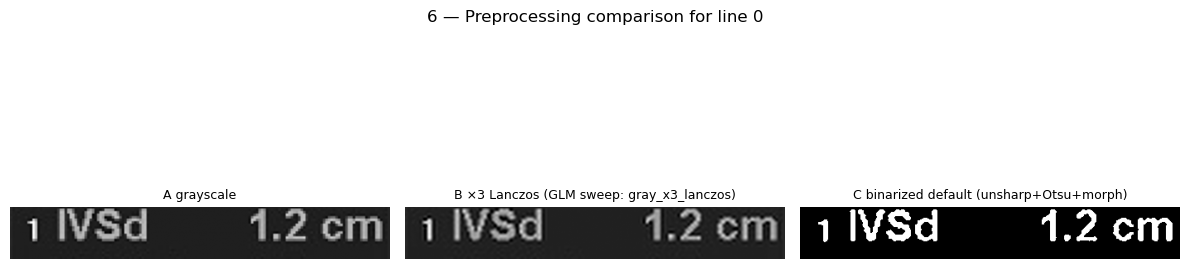

In [8]:
LINE_IX = 0

from app.ocr.preprocessing import (
    DEFAULT_CONTRAST_MODE,
    DEFAULT_SCALE_ALGO,
    DEFAULT_SCALE_FACTOR,
    _to_gray,
    preprocess_gray_x3_lanczos,
    preprocess_roi,
)

if LINE_IX >= len(line_crops):
    raise IndexError("LINE_ix out of range — no line crops.")

crop = line_crops[LINE_IX]
stages = {
    "A grayscale": _to_gray(crop),
    "B ×3 Lanczos (GLM sweep: gray_x3_lanczos)": preprocess_gray_x3_lanczos(crop),
    "C binarized default (unsharp+Otsu+morph)": preprocess_roi(
        crop,
        scale_factor=DEFAULT_SCALE_FACTOR,
        scale_algo=DEFAULT_SCALE_ALGO,
        contrast_mode=DEFAULT_CONTRAST_MODE,
    ),
}
keys = list(stages.keys())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, keys):
    im = stages[k]
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
    ax.set_title(k, fontsize=9)
    ax.axis("off")
plt.suptitle(f"6 — Preprocessing comparison for line {LINE_IX}", y=1.02)
plt.tight_layout()
plt.show()

## Slide 9 - Multi-View Strategy for Hard Lines

## What appears on screen
- Three OCR-ready views of the same line:
  - **gray_x3_lanczos** (GLM-optimized from the sweep — primary view in this notebook)
  - **default** binarized pipeline (unsharp + Otsu + morph)
  - **clahe** variant (CLAHE + same binarization stack as `preprocess_roi`)



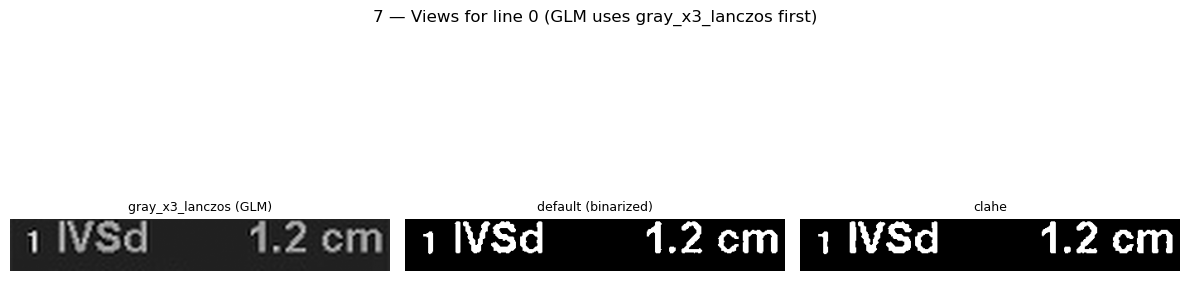

In [9]:
from app.ocr.preprocessing import preprocess_gray_x3_lanczos, preprocess_roi

views = {
    "gray_x3_lanczos (GLM)": preprocess_gray_x3_lanczos(line_crops[LINE_IX]),
    "default (binarized)": preprocess_roi(
        line_crops[LINE_IX],
        scale_factor=DEFAULT_SCALE_FACTOR,
        scale_algo=DEFAULT_SCALE_ALGO,
        contrast_mode=DEFAULT_CONTRAST_MODE,
    ),
    "clahe": preprocess_roi(
        line_crops[LINE_IX],
        scale_factor=DEFAULT_SCALE_FACTOR,
        scale_algo=DEFAULT_SCALE_ALGO,
        contrast_mode="clahe",
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, img) in zip(axes, views.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(name, fontsize=9)
    ax.axis("off")
plt.suptitle(f"7 — Views for line {LINE_IX} (GLM uses gray_x3_lanczos first)", y=1.05)
plt.tight_layout()
plt.show()

## Slide 10 - OCR Extraction and Structured Output



Engine ready: glm-ocr (line crops: preprocess_gray_x3_lanczos)
line 0: '1 IVSd 1.2 cm' (conf=0.990, tokens=1)
line 1: 'LVIDd 4.7cm' (conf=0.990, tokens=1)
line 2: 'LVPWd 1.1cm' (conf=0.990, tokens=1)


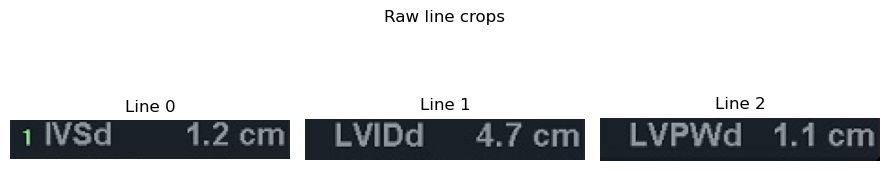

In [10]:
# GLM-OCR (optional): worker loads in the `glm_ocr` conda env — startup can take ~minutes the first time.
RUN_GLM_OCR = True
RUN_GLM_FULL_PIPELINE = False

from app.ocr.preprocessing import (
    DEFAULT_CONTRAST_MODE,
    DEFAULT_SCALE_ALGO,
    DEFAULT_SCALE_FACTOR,
    preprocess_gray_x3_lanczos,
    preprocess_roi,
)

if RUN_GLM_OCR:
    from app.pipeline.ocr.ocr_engines import UnavailableOcrEngineError, build_engine

    try:
        glm = build_engine("glm-ocr")
    except UnavailableOcrEngineError as exc:
        print("GLM-OCR unavailable:", exc)
        print(
            "Fix:\n"
            "  mamba env update -f envs/glm_ocr.yml --prune\n"
            "The app also probes ~/miniforge3, ~/mambaforge, $CONDA_EXE, etc. if mamba is not on PATH.\n"
            "Or: GLM_OCR_RUNNER=python and pip-install the pip: section of envs/glm_ocr.yml into this kernel."
        )
    except Exception as exc:
        print("GLM-OCR failed to start:", exc)
    else:
        print(f"Engine ready: {glm.name} (line crops: preprocess_gray_x3_lanczos)")
        for i, crop in enumerate(line_crops):
            proc = preprocess_gray_x3_lanczos(crop)
            result = glm.extract(proc)
            print(
                f"line {i}: {result.text!r} "
                f"(conf={result.confidence:.3f}, tokens={len(result.tokens)})"
            )

if RUN_GLM_FULL_PIPELINE:
    from app.models.types import PipelineRequest
    from app.pipeline.ai_pipeline import PipelineConfig
    from app.pipeline.echo_ocr_pipeline import EchoOcrPipeline

    dicom_path = DICOM_PATH
    if dicom_path is None:
        raise RuntimeError("Run the setup cell first — no sample DICOM (DICOM_PATH is unset).")

    pipe = EchoOcrPipeline(
        config=PipelineConfig(
            parameters={
                "max_frames": 1,
                "ocr_engine": "glm-ocr",
            }
        )
    )
    pipe.ensure_components()
    res = pipe.run(PipelineRequest(dicom_path=dicom_path, parameters={"max_frames": 1}))
    print("Full pipeline:", res.status, res.error)
    if res.ai_result:
        for m in res.ai_result.measurements:
            print(m.name, m.value, m.unit)

if not RUN_GLM_OCR and not RUN_GLM_FULL_PIPELINE:
    print("Set RUN_GLM_OCR or RUN_GLM_FULL_PIPELINE to True to run GLM-OCR.")

#show the line crops
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.2 * rows))
axes = np.atleast_1d(axes).ravel()
for i, crop in enumerate(line_crops):
    axes[i].imshow(crop)
    axes[i].set_title(f"Line {i}")
    axes[i].axis("off")
plt.suptitle("Raw line crops", y=1.02)
plt.tight_layout()
plt.show()

#Tesseract on lines (no GLM env): swap engine
#engine = build_engine("tesseract")
#for i, crop in enumerate(line_crops):
#    proc = preprocess_roi(crop, scale_factor=DEFAULT_SCALE_FACTOR, scale_algo=DEFAULT_SCALE_ALGO, contrast_mode=DEFAULT_CONTRAST_MODE)
#    print(i, repr(engine.extract(proc).text))